# Heart Disease — Model Evaluation
ROC curve, feature importance, and confusion matrix for the
saved model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix


## 1. Load saved model and test data

In [2]:
model = joblib.load("../../models/heart_disease_model.pkl")

X_test = pd.read_csv("../../data/processed/heart_disease_X_test.csv")
y_test = pd.read_csv("../../data/processed/heart_disease_y_test.csv").squeeze()


## 2. Classification report

In [3]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))


              precision    recall  f1-score   support

  No Disease       0.95      0.64      0.77        28
     Disease       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



## 3. ROC curve

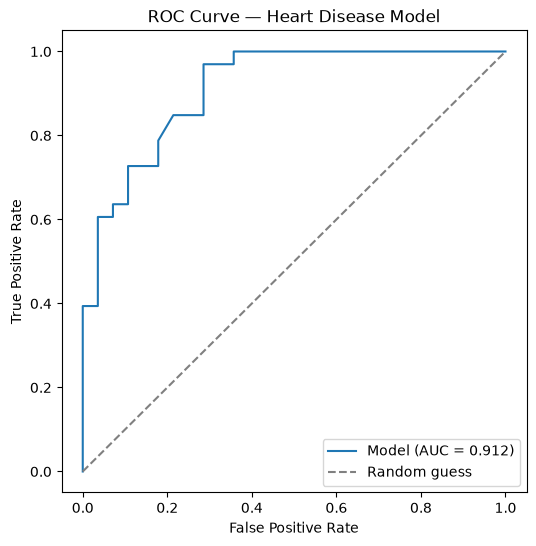

In [4]:
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Model (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Heart Disease Model")
plt.legend()
plt.savefig("../../reports/figures/heart_disease/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Feature importance

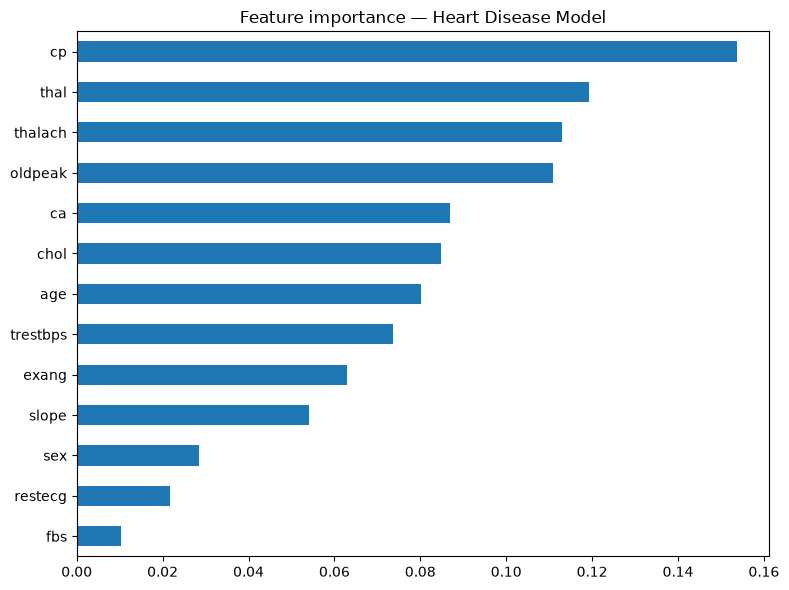

In [5]:
if hasattr(model, "feature_importances_"):
    importances = pd.Series(model.feature_importances_, index=X_test.columns)
elif hasattr(model, "coef_"):
    importances = pd.Series(model.coef_[0], index=X_test.columns)
else:
    importances = None

if importances is not None:
    importances = importances.sort_values(ascending=True)
    plt.figure(figsize=(8, 6))
    importances.plot(kind="barh")
    plt.title("Feature importance — Heart Disease Model")
    plt.tight_layout()
    plt.savefig("../../reports/figures/heart_disease/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()


## 5. Confusion matrix heatmap

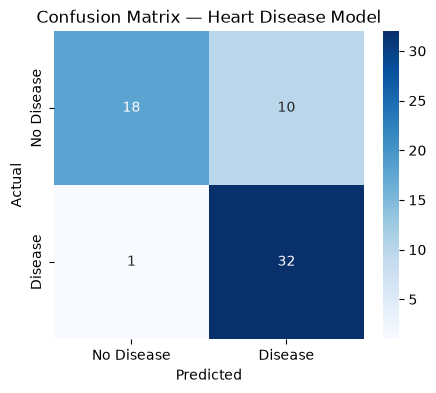

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Heart Disease Model")
plt.savefig("../../reports/figures/heart_disease/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## Next step
Heart disease pipeline complete. Repeat this same pattern
for CKD, hypertension, and liver disease next.